<h1>SQ4 Code</h1>
This notebook contains the code which assists the answering of subquestion 4: <em><strong>How do clusters based on structural characteristics differ in the predictive role of environmental attitudes in mode choice?</em></strong>


This is done in the following steps:

1. Data preperation and selection
2. Parameter Estimation
3. Clustering
4. Analysis of Clusters by Logistic Regression
5. Addition to model

## Data preperation

### Imports

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
from pathlib import Path

from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import FactorAnalysis
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, f1_score, silhouette_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

import statsmodels.api as sm

### Data Loading

In [2]:
filename = "ModeChoiceOptima_cleaned.csv"
base_path = Path("C:/Users/kaimo/Documents/MSc/Y1Q3/ML for Transport/Project") #Put your own base here
paths = list(base_path.rglob(filename))
for p in paths:
    print(p)
df = pd.read_csv(paths[0])

C:\Users\kaimo\Documents\MSc\Y1Q3\ML for Transport\Project\ModeChoiceOptima_cleaned.csv


### Aggregating attitudes

In [3]:
Env_data = df[['Envir01','Envir02','Envir03','Envir04','Envir05','Envir06']]

scaler = StandardScaler()
Env_data_scaled = scaler.fit_transform(Env_data)

fa = FactorAnalysis(n_components=1, random_state=0)  
Env_data_factors = fa.fit_transform(Env_data_scaled)
loadings = fa.components_
loadings *= -1 #Alternated such that high scores are positive based on output FA
Env_data_factors *= -1

df['Env_score'] = Env_data_factors
scaler = StandardScaler()
df[['Env_score_norm']] = scaler.fit_transform(df[['Env_score']])


C:\Users\kaimo\AppData\Local\Temp\ipykernel_32064\3249135292.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['Env_score'] = Env_data_factors
C:\Users\kaimo\AppData\Local\Temp\ipykernel_32064\3249135292.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[['Env_score_norm']] = scaler.fit_transform(df[['Env_score']])


### Aggregating constraints

In [4]:
df['Time_ratio'] = df['TimePT'] - df['TimeCar'] 
df['Cost_ratio'] = df['CostPT'] - df['CostCar']
df = df[(df['CostPT'] != 0) & (df['CostCar'] != 0)]
df = df[(df['TimePT'] != 0) & (df['TimeCar'] != 0)]
df[['Time_ratio','Cost_ratio']] = scaler.fit_transform(df[['Time_ratio','Cost_ratio']])
df_cluster = df[['Time_ratio', 'Cost_ratio']]

C:\Users\kaimo\AppData\Local\Temp\ipykernel_32064\617048538.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['Time_ratio'] = df['TimePT'] - df['TimeCar']
C:\Users\kaimo\AppData\Local\Temp\ipykernel_32064\617048538.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['Cost_ratio'] = df['CostPT'] - df['CostCar']


## Parameter Estimation

In [5]:
k_values = range(2, 16)

inertia_vals = []
sil_vals = []
for k in k_values:
    km = KMeans(n_clusters=k, init='k-means++', random_state=0, n_init=50)
    labels = km.fit_predict(df_cluster)
    inertia_vals.append(km.inertia_)
    sil_vals.append(silhouette_score(df_cluster, labels))  

C:\Users\kaimo\anaconda3\envs\py312\Lib\site-packages\threadpoolctl.py:1214: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


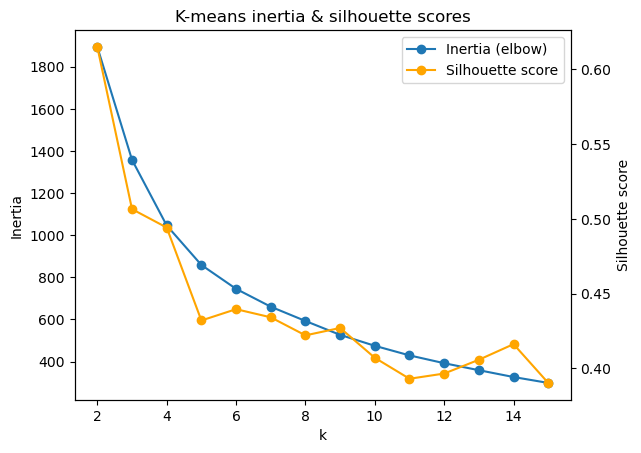

In [6]:
fig, ax = plt.subplots()

line1 = ax.plot(k_values, inertia_vals, 'o-', label='Inertia (elbow)')
ax.set_xlabel('k')
ax.set_ylabel('Inertia')
ax2 = ax.twinx()
line2 = ax2.plot(k_values, sil_vals, 'o-', color='orange', label='Silhouette score')
ax2.set_ylabel('Silhouette score')

lines = line1 + line2
labels = [l.get_label() for l in lines]
ax.legend(lines, labels, loc='best')
plt.title('K-means inertia & silhouette scores')
plt.savefig("Parameter_clustering.jpg")
plt.show()

## Clustering

In [7]:
k = 5 
kmeans = KMeans(n_clusters=k, init='k-means++', random_state=0, n_init=50) 
labels = kmeans.fit_predict(df_cluster) 
cluster = pd.Series(index=df.index, dtype="Int64") 
cluster.loc[df_cluster.index] = labels 
df["cluster"] = cluster 
n_clusters = len(df_cluster.index) 
dummies = pd.get_dummies(df["cluster"], prefix="cluster") 
dummies = dummies.reindex(df.index, fill_value=0).astype(int) 
df = df.drop(columns=[c for c in df.columns if c.startswith("cluster_")], errors="ignore") 
df = pd.concat([df, dummies], axis=1)

C:\Users\kaimo\AppData\Local\Temp\ipykernel_32064\195157888.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["cluster"] = cluster


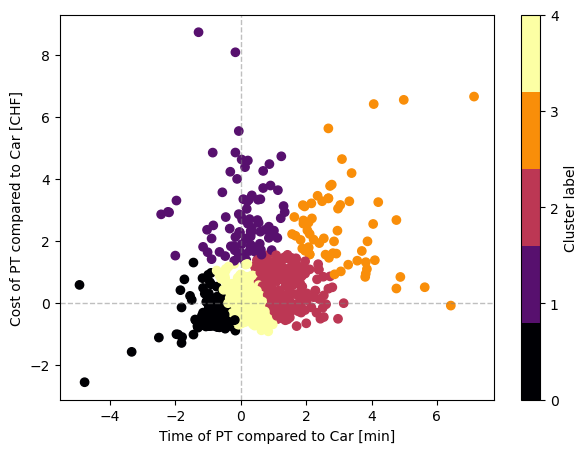

In [8]:
cmap = plt.colormaps['inferno'].resampled(k)
plt.figure(figsize=(7, 5))
sc = plt.scatter(df_cluster['Time_ratio'], df_cluster['Cost_ratio'], c=labels, cmap=cmap)
plt.axhline(0, linestyle='--', linewidth=1, alpha=0.5, color='gray')
plt.axvline(0, linestyle='--', linewidth=1, alpha=0.5, color='gray')
plt.xlabel('Time of PT compared to Car [min]')
plt.ylabel('Cost of PT compared to Car [CHF]')
cbar = plt.colorbar(sc, ticks=np.arange(k))
cbar.set_label('Cluster label')
plt.savefig("Clusterpoints.jpg", dpi=300)

### Cluster Data

In [9]:
choice_pct = (df.groupby('cluster')['Choice'].value_counts(normalize=True).unstack(fill_value=0) * 100)
print(choice_pct)

avg_constraints = df.groupby('cluster')[['Time_ratio', 'Cost_ratio', 'Env_score_norm']].mean()
print(avg_constraints)

print(df['cluster'].value_counts())

Choice           0          1         2
cluster                                
0        35.644769  56.812652  7.542579
1        58.241758  40.659341  1.098901
2        10.762332  88.789238  0.448430
3        13.114754  86.885246  0.000000
4        24.744027  73.890785  1.365188
         Time_ratio  Cost_ratio  Env_score_norm
cluster                                        
0         -0.713721   -0.501690       -0.002206
1          0.044269    2.722115        0.213257
2          1.374191    0.377720       -0.059059
3          3.049340    2.446518        0.018012
4          0.153918   -0.117394       -0.004922
cluster
0    822
4    586
2    223
1     91
3     61
Name: count, dtype: Int64


### Logistic Regression

In [10]:
cluster_models = {}
results = []
for cluster in sorted(df['cluster'].unique()):
    df_log = df[df['cluster'] == cluster].copy()
    df_log['Env_choice'] = (df_log['Choice'] == 1)
    X = sm.add_constant(df_log[['Env_score']])
    y = df_log['Env_choice']
    model = sm.Logit(y, X)
    result = model.fit(disp=False)
    cluster_models[cluster] = result
    results.append({
        'cluster': cluster,
        'Coefficient $B_1$': result.params['Env_score'],
        'Intercept $B_0$': result.params['const'],
        'p_$B_1$': result.pvalues['Env_score'],
        'p_intercept_$B_0$': result.pvalues['const']
    })

In [11]:
summary_df = pd.DataFrame(results).set_index('cluster')
print(summary_df)

         Coefficient $B_1$  Intercept $B_0$   p_$B_1$  p_intercept_$B_0$
cluster                                                                 
0                -0.384721         0.281822  0.000013       7.857470e-05
1                -0.669641        -0.278090  0.014858       2.148980e-01
2                -0.538094         2.129831  0.052234       3.828692e-21
3                 0.621383         1.934034  0.335962       9.568941e-07
4                -0.507126         1.081404  0.000067       1.608130e-28


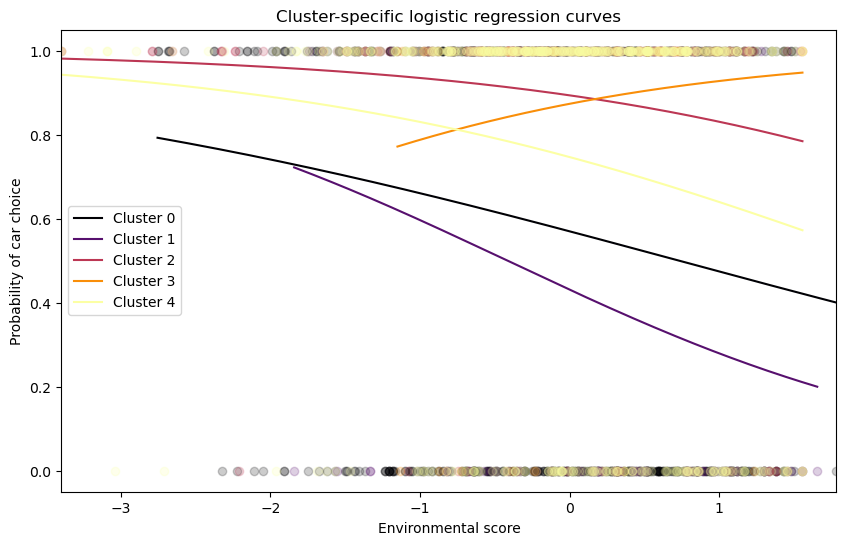

In [12]:
clusters = sorted(df["cluster"].dropna().unique())
plt.figure(figsize=(10, 6))
for i, cl in enumerate(clusters):
    model = cluster_models[cl]
    d = df[df['cluster'] == cl]
    x = np.linspace(d['Env_score'].min(), d['Env_score'].max(), 200)
    X = sm.add_constant(pd.DataFrame({'Env_score': x}))
    p = model.predict(X)
    plt.plot(x, p, color=cmap(i), label=f'Cluster {int(cl)}')
    plt.scatter(d['Env_score'], (d['Choice'] == 1), color=cmap(i), alpha=0.2)
    
plt.xlabel('Environmental score')
plt.ylabel('Probability of car choice')
plt.title('Cluster-specific logistic regression curves')
plt.xlim(df['Env_score'].min(), df['Env_score'].max())
plt.legend()
plt.savefig("LogRegressionCurves.jpg")


## Expansion of Baseline Model

Run of Contextual Factors and Environmental Factors. For baseline and structured execution and explanation, see corresponding subquestion

In [13]:
baseline_features = [
    "age", "Gender", "Income", "Education", "NbCar", "CarAvail", "NbHousehold", "NbChild", "NbTrajects", "TripPurpose", "distance_km"]

# Contextual, environmental and clustering features
struct_features = ["TimePT", "TimeCar", "CostPT", "CostCar", "frequency", "ClassifCodeLine"]
env_features = ["Envir01", "Envir02", "Envir03", "Envir04", "Envir05", "Envir06"]
clustering_features = ['cluster_0', 'cluster_1', 'cluster_2', 'cluster_3', 'cluster_4']

X_sq4_1 = df[baseline_features + struct_features + env_features]
y_sq4_1 = df["Choice"]

categorical_features = ["Gender", "TripPurpose", "CarAvail", "frequency", "ClassifCodeLine"]
numerical_features = ["age", "Income", "Education", "NbCar", "NbHousehold", "NbChild", "NbTrajects", "distance_km", "TimePT", "TimeCar", "CostPT", "CostCar", "Envir01", "Envir02", "Envir03", "Envir04", "Envir05", "Envir06"]


numeric_transformer = Pipeline([("imputer", SimpleImputer(strategy="median"))])
categorical_transformer = Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(handle_unknown="ignore"))])

preprocessor = ColumnTransformer([("num", numeric_transformer, numerical_features), ("cat", categorical_transformer, categorical_features)])

X_train, X_test, y_train, y_test = train_test_split(X_sq4_1, y_sq4_1, test_size=0.2, random_state=42, stratify=y_sq4_1)
rf_model = Pipeline([("preprocessor", preprocessor),("classifier", RandomForestClassifier(n_estimators=200, max_depth=None, min_samples_leaf=2, max_features="sqrt", criterion="gini", bootstrap=True, class_weight="balanced", random_state=42, n_jobs=-1))])
rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 (weighted):", f1_score(y_test, y_pred, average="weighted"))

print(classification_report(y_test, y_pred, digits=3))


Accuracy: 0.8011204481792717
F1 (weighted): 0.7929987444526508
              precision    recall  f1-score   support

           0      0.768     0.600     0.674       105
           1      0.819     0.912     0.863       238
           2      0.600     0.429     0.500        14

    accuracy                          0.801       357
   macro avg      0.729     0.647     0.679       357
weighted avg      0.795     0.801     0.793       357



Addition of cluster data/dummies

In [14]:
X_sq4_2 = df[baseline_features + struct_features + env_features + clustering_features]
y_sq4_2 = df["Choice"]

categorical_features = ["Gender", "TripPurpose", "CarAvail", "frequency", "ClassifCodeLine", 'cluster_0', 'cluster_1', 'cluster_2', 'cluster_3', 'cluster_4']
numerical_features = ["age", "Income", "Education", "NbCar", "NbHousehold", "NbChild", "NbTrajects", "distance_km", "TimePT", "TimeCar", "CostPT", "CostCar", "Envir01", "Envir02", "Envir03", "Envir04", "Envir05", "Envir06"]


numeric_transformer = Pipeline([("imputer", SimpleImputer(strategy="median"))])
categorical_transformer = Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(handle_unknown="ignore"))])

preprocessor = ColumnTransformer([("num", numeric_transformer, numerical_features), ("cat", categorical_transformer, categorical_features)])

X_train, X_test, y_train, y_test = train_test_split(X_sq4_2, y_sq4_2, test_size=0.2, random_state=42, stratify=y_sq4_1)
rf_model = Pipeline([("preprocessor", preprocessor),("classifier", RandomForestClassifier(n_estimators=200, max_depth=None, min_samples_leaf=2, max_features="sqrt", criterion="gini", bootstrap=True, class_weight="balanced", random_state=42, n_jobs=-1))])
rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 (weighted):", f1_score(y_test, y_pred, average="weighted"))

print(classification_report(y_test, y_pred, digits=3))

Accuracy: 0.7927170868347339
F1 (weighted): 0.7883010615127851
              precision    recall  f1-score   support

           0      0.725     0.629     0.673       105
           1      0.827     0.882     0.854       238
           2      0.583     0.500     0.538        14

    accuracy                          0.793       357
   macro avg      0.712     0.670     0.689       357
weighted avg      0.787     0.793     0.788       357



Additional and unused

Text(0.5, 0, 'Cluster')

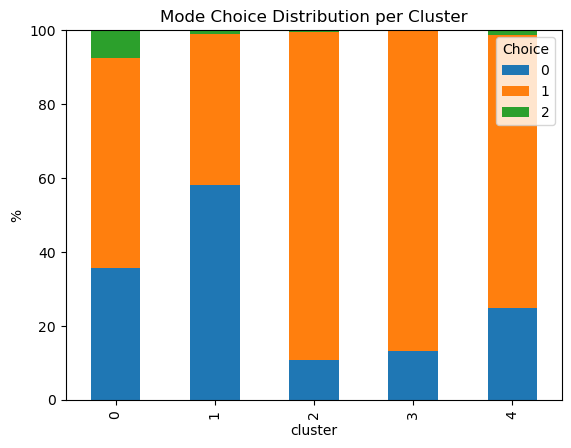

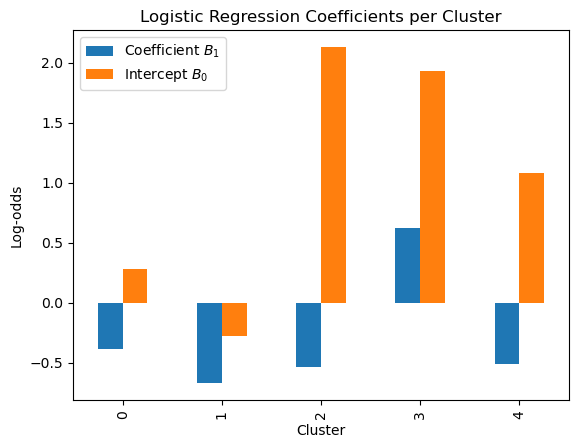

In [15]:
choice_pct.plot(kind='bar', stacked=True)
plt.ylabel('%')
plt.title('Mode Choice Distribution per Cluster')
plt.legend(title='Choice')

summary_df[['Coefficient $B_1$', 'Intercept $B_0$']].plot(kind='bar')
plt.title('Logistic Regression Coefficients per Cluster')
plt.ylabel('Log-odds')
plt.xlabel('Cluster')